## CELLULE — Initialization

In [1]:
# ============================================================
# CELLULE — Évaluation 100 épisodes sur tous les modèles
# ============================================================

# — Bibliothèques standard
import sys                               # manipulation du path Python
import numpy             as np           # calcul vectoriel

# — Barre de progression
from tqdm.notebook       import tqdm     # progression visuelle Jupyter

# — Stable-Baselines3
from stable_baselines3                   import PPO, DQN          # algorithmes
from stable_baselines3.common.evaluation import evaluate_policy   # évaluation
from stable_baselines3.common.monitor    import Monitor           # wrapper stats

# — Chemins
from pathlib             import Path     # chemins portables

# Ajout du dossier core au path pour les imports
import sys
BASE       = Path().resolve().parent   # notebooks/ → m11_ocr/
CORE       = BASE / 'core'             # env_utils, metrics, viz_utils
if str(CORE) not in sys.path:
    sys.path.insert(0, str(CORE))
    
# — Modules core
from env_utils           import make_env # création environnement
from datetime import datetime        # pour ajouter date dans les noms de fichiers

ts       = datetime.now().strftime("%y%m%d_%H%M%S")   # 250619_143022

# ----------------------------------------------------------
# Configuration des chemins
# ----------------------------------------------------------
BASE   = Path().resolve().parent         # notebooks/ → m11_ocr/
CORE   = BASE / 'core'                   # modules core
MODELS = BASE / 'models'                 # modèles sauvegardés

if str(CORE) not in sys.path:
    sys.path.insert(0, str(CORE))

ENV_ID = "LunarLander-v3"               # identifiant Gymnasium
SEED   = 42                              # graine de reproductibilité

# ----------------------------------------------------------
# Listes des modèles à évaluer
# ----------------------------------------------------------
MODELES_PPO = [
    "best_ppo/best_model.zip",
    "mission_260623_101350_ppo_lunarlander_226_best.zip",
    "mission_260623_101350_ppo_lunarlander_226.zip",
    "mission_260623_005440_ppo_lunarlander_226_best.zip",
    "mission_260623_005440_ppo_lunarlander_226.zip",
    "mission_260622_214348_ppo_lunarlander_226_best.zip",
    "mission_260622_214348_ppo_lunarlander_226.zip",
]

MODELES_DQN = [
    "best_dqn/best_model.zip",
    "mission_260623_101350_dqn_lunarlander_226_best.zip",
    "mission_260623_101350_dqn_lunarlander_226.zip",
    "mission_260623_101350_dqn_lunarlander_222.zip",
    "mission_260623_005440_dqn_lunarlander_226_best.zip",
    "mission_260623_005440_dqn_lunarlander_226.zip",
    "mission_260623_005440_dqn_lunarlander_222.zip",
    "mission_260622_214348_dqn_lunarlander_226_best.zip",
    "mission_260622_214348_dqn_lunarlander_226.zip",
    "mission_260622_214348_dqn_lunarlander_222.zip",
]

print("Imports et Configuration Done!")

Imports et Configuration Done!


## CELLULE - FUNTIONS

In [2]:
# ##########################################################
# Fonction d'évaluation — 100 épisodes avec barre tqdm
# ##########################################################
def evaluer_modele(chemin_zip, algo_cls, env_id, seed, n_episodes=100):
    """
    Évalue un modèle SB3 sur N épisodes avec politique déterministe.

    Paramètres
    ----------
    chemin_zip : Path   Chemin vers le fichier .zip du modèle.
    algo_cls   : class  Classe SB3 (PPO ou DQN).
    env_id     : str    Identifiant de l'environnement Gymnasium.
    seed       : int    Graine pour la reproductibilité.
    n_episodes : int    Nombre d'épisodes d'évaluation.

    Retourne
    --------
    dict  Résultats : mean, std, n_succes, taux_succes, valide.
          None si le fichier est introuvable.
    """
    # ----------------------------------------------------------
    # Vérification existence du fichier
    # ----------------------------------------------------------
    if not chemin_zip.exists():
        return None

    # ----------------------------------------------------------
    # Chargement du modèle
    # ----------------------------------------------------------
    model = algo_cls.load(str(chemin_zip))

    # ----------------------------------------------------------
    # Création de l'environnement d'évaluation
    # ----------------------------------------------------------
    env = Monitor(make_env(env_id, render_mode=None, seed=seed))

    # ----------------------------------------------------------
    # Boucle d'évaluation avec barre de progression
    # ----------------------------------------------------------
    rewards  = []
    n_succes = 0

    with tqdm(
        range(n_episodes),
        desc    = f"  {chemin_zip.name[:45]}",
        unit    = "ep",
        colour  = "#534AB7",
        leave   = False,
    ) as pbar:
        for ep in pbar:
            obs, _     = env.reset(seed=seed + ep)
            total_r    = 0.0
            terminated = False
            truncated  = False

            while not (terminated or truncated):
                action, _                        = model.predict(
                                                   obs, deterministic=True)
                obs, r, terminated, truncated, _ = env.step(action)
                total_r                         += r

            rewards.append(total_r)
            if total_r >= 200:
                n_succes += 1

            # Mise à jour métriques toutes les 10 épisodes
            if (ep + 1) % 10 == 0:
                pbar.set_postfix({
                    "moy"    : f"{np.mean(rewards):+.1f}",
                    "succès" : f"{n_succes}/{ep+1}",
                })

    env.close()

    mean_r = np.mean(rewards)
    std_r  = np.std(rewards)

    return {
        "mean_reward" : round(mean_r,   2),
        "std_reward"  : round(std_r,    2),
        "n_succes"    : n_succes,
        "taux_succes" : round(n_succes / n_episodes * 100, 1),
        "valide"      : mean_r >= 200,
    }


# ##########################################################
# Boucle principale — évaluation de tous les modèles
# ##########################################################
def evaluer_liste(liste_noms, algo_cls, algo_nom):
    """
    Évalue tous les modèles d'une liste et affiche un tableau récap.

    Paramètres
    ----------
    liste_noms : list   Noms de fichiers relatifs à MODELS/.
    algo_cls   : class  Classe SB3 (PPO ou DQN).
    algo_nom   : str    Nom de l'algorithme pour l'affichage.
    """
    print("\n" + "=" * 70)
    print(f"ÉVALUATION {algo_nom} — {len(liste_noms)} MODÈLES × 100 ÉPISODES")
    print("=" * 70)

    resultats = {}

    for nom in liste_noms:
        chemin = MODELS / Path(nom)
        print(f"\n  ▶ {nom}")

        res = evaluer_modele(chemin, algo_cls, ENV_ID, SEED)

        if res is None:
            print(f"    ✗ Fichier introuvable : {chemin}")
            continue

        resultats[nom] = res

        critere = "✓ VALIDÉ" if res["valide"] else "✗ NON ATTEINT"
        print(f"    Récompense moyenne..: {res['mean_reward']:+.2f}")
        print(f"    Écart-type..........: {res['std_reward']:.2f}")
        print(f"    Épisodes réussis....: {res['n_succes']} / 100")
        print(f"    Taux de succès......: {res['taux_succes']:.1f} %")
        print(f"    Critère ≥ 200.......: {critere}")

    # ----------------------------------------------------------
    # Tableau récapitulatif trié par récompense moyenne
    # ----------------------------------------------------------
    if not resultats:
        print("\n  Aucun modèle évalué.")
        return resultats

    print("\n" + "-" * 70)
    print(f"  RÉCAPITULATIF {algo_nom} — classement par récompense moyenne")
    print("-" * 70)
    print(f"  {'Modèle':<48} {'Moy':>7} {'Std':>6} {'Succ':>5} {'≥200':>6}")
    print(f"  {'-'*48} {'-'*7} {'-'*6} {'-'*5} {'-'*6}")

    for nom, res in sorted(
        resultats.items(),
        key    = lambda x: x[1]["mean_reward"],
        reverse= True,
    ):
        critere = "✓" if res["valide"] else "✗"
        label   = Path(nom).name[:46]
        print(
            f"  {label:<48} "
            f"{res['mean_reward']:>+7.1f} "
            f"{res['std_reward']:>6.1f} "
            f"{res['n_succes']:>4d}% "
            f"{critere:>6}"
        )

    # Meilleur modèle
    meilleur_nom = max(resultats, key=lambda x: resultats[x]["mean_reward"])
    meilleur     = resultats[meilleur_nom]
    print(f"\n  🏆 Meilleur {algo_nom}...: {Path(meilleur_nom).name}")
    print(f"     Récompense.........: {meilleur['mean_reward']:+.2f} "
          f"± {meilleur['std_reward']:.2f}")

    return resultats

print("Loaded funtions!")

Loaded funtions!


## CZLLULZ - Lancement des évaluations

In [3]:

# ----------------------------------------------------------
# Lancement des évaluations
# ----------------------------------------------------------
resultats_ppo = evaluer_liste(MODELES_PPO, PPO, "PPO")
resultats_dqn = evaluer_liste(MODELES_DQN, DQN, "DQN")

# ----------------------------------------------------------
# Comparaison finale PPO vs DQN (meilleurs modèles)
# ----------------------------------------------------------
print("\n" + "=" * 70)
print("COMPARAISON FINALE — MEILLEUR PPO vs MEILLEUR DQN")
print("=" * 70)

if resultats_ppo:
    best_ppo_nom = max(resultats_ppo, key=lambda x: resultats_ppo[x]["mean_reward"])
    best_ppo     = resultats_ppo[best_ppo_nom]
    print(f"\n  PPO — {Path(best_ppo_nom).name}")
    print(f"    Récompense moyenne..: {best_ppo['mean_reward']:+.2f} "
          f"± {best_ppo['std_reward']:.2f}")
    print(f"    Critère ≥ 200.......: "
          f"{'✓ VALIDÉ' if best_ppo['valide'] else '✗ NON ATTEINT'}")

if resultats_dqn:
    best_dqn_nom = max(resultats_dqn, key=lambda x: resultats_dqn[x]["mean_reward"])
    best_dqn     = resultats_dqn[best_dqn_nom]
    print(f"\n  DQN — {Path(best_dqn_nom).name}")
    print(f"    Récompense moyenne..: {best_dqn['mean_reward']:+.2f} "
          f"± {best_dqn['std_reward']:.2f}")
    print(f"    Critère ≥ 200.......: "
          f"{'✓ VALIDÉ' if best_dqn['valide'] else '✗ NON ATTEINT'}")


ÉVALUATION PPO — 7 MODÈLES × 100 ÉPISODES

  ▶ best_ppo/best_model.zip


  best_model.zip:   0%|          | 0/100 [00:00<?, ?ep/s]

    Récompense moyenne..: +239.01
    Écart-type..........: 51.32
    Épisodes réussis....: 88 / 100
    Taux de succès......: 88.0 %
    Critère ≥ 200.......: ✓ VALIDÉ

  ▶ mission_260623_101350_ppo_lunarlander_226_best.zip


  mission_260623_101350_ppo_lunarlander_226_bes:   0%|          | 0/100 [00:00<?, ?ep/s]

    Récompense moyenne..: +239.01
    Écart-type..........: 51.32
    Épisodes réussis....: 88 / 100
    Taux de succès......: 88.0 %
    Critère ≥ 200.......: ✓ VALIDÉ

  ▶ mission_260623_101350_ppo_lunarlander_226.zip


...

    Récompense moyenne..: +224.44
    Écart-type..........: 35.89
    Épisodes réussis....: 78 / 100
    Taux de succès......: 78.0 %
    Critère ≥ 200.......: ✓ VALIDÉ

  ▶ mission_260622_214348_dqn_lunarlander_226.zip


  mission_260622_214348_dqn_lunarlander_226.zip:   0%|          | 0/100 [00:00<?, ?ep/s]

    Récompense moyenne..: +224.44
    Écart-type..........: 35.89
    Épisodes réussis....: 78 / 100
    Taux de succès......: 78.0 %
    Critère ≥ 200.......: ✓ VALIDÉ

  ▶ mission_260622_214348_dqn_lunarlander_222.zip


  mission_260622_214348_dqn_lunarlander_222.zip:   0%|          | 0/100 [00:00<?, ?ep/s]

    Récompense moyenne..: +229.96
    Écart-type..........: 31.61
    Épisodes réussis....: 82 / 100
    Taux de succès......: 82.0 %
    Critère ≥ 200.......: ✓ VALIDÉ

----------------------------------------------------------------------
  RÉCAPITULATIF DQN — classement par récompense moyenne
----------------------------------------------------------------------
  Modèle                                               Moy    Std  Succ   ≥200
  ------------------------------------------------ ------- ------ ----- ------
  mission_260623_101350_dqn_lunarlander_222.zip     +230.0   31.6   82%      ✓
  mission_260623_005440_dqn_lunarlander_222.zip     +230.0   31.6   82%      ✓
  mission_260622_214348_dqn_lunarlander_222.zip     +230.0   31.6   82%      ✓
  best_model.zip                                    +224.4   35.9   78%      ✓
  mission_260623_101350_dqn_lunarlander_226_best    +224.4   35.9   78%      ✓
  mission_260623_101350_dqn_lunarlander_226.zip     +224.4   35.9   78%      ✓


## CELLULE — Sauvegarde des résultats pour graphiques comparatifs

In [4]:
# ============================================================
# CELLULE — Sauvegarde des résultats pour graphiques comparatifs
# ============================================================

# — Bibliothèques standard
import json                              # sérialisation JSON
import datetime                          # horodatage des résultats
from pathlib import Path                 # chemins portables

from datetime import datetime        # pour ajouter date dans les noms de fichiers

ts       = datetime.now().strftime("%y%m%d_%H%M%S")   # 250619_143022

# ----------------------------------------------------------
# Résultats à sauvegarder
# Alimentés par la cellule d'évaluation précédente
# (resultats_ppo, resultats_dqn doivent exister en mémoire)
# ----------------------------------------------------------
resultats_comparatifs = {
    "date"      : datetime.now().isoformat(),
    "env_id"    : ENV_ID,
    "n_episodes": 100,
    "seed"      : SEED,
    "PPO"       : {},
    "DQN"       : {},
}

# ----------------------------------------------------------
# Remplir PPO
# ----------------------------------------------------------
for nom, res in resultats_ppo.items():
    resultats_comparatifs["PPO"][nom] = {
        "mean_reward" : float(res["mean_reward"]) if res["mean_reward"] is not None else None,
        "std_reward"  : float(res["std_reward"]) if res["std_reward"] is not None else None,
        "n_succes"    : int(res["n_succes"]) if res["n_succes"] is not None else 0,
        "taux_succes" : float(res["taux_succes"]) if res["taux_succes"] is not None else 0.0,
        "valide"      : bool(res["valide"]), # <--- AQUÍ SE CORRIGE EL ERROR
        "algo"        : "PPO",
    }

# ----------------------------------------------------------
# Remplir DQN
# ----------------------------------------------------------
for nom, res in resultats_dqn.items():
    resultats_comparatifs["DQN"][nom] = {
        "mean_reward" : float(res["mean_reward"]) if res["mean_reward"] is not None else None,
        "std_reward"  : float(res["std_reward"]) if res["std_reward"] is not None else None,
        "n_succes"    : int(res["n_succes"]) if res["n_succes"] is not None else 0,
        "taux_succes" : float(res["taux_succes"]) if res["taux_succes"] is not None else 0.0,
        "valide"      : bool(res["valide"]), # <--- AQUÍ SE CORRIGE EL ERROR
        "algo"        : "DQN",
    }

# ----------------------------------------------------------
# Sauvegarde JSON
# ----------------------------------------------------------
chemin_json = MODELS / f"comparaison_{ts}_ppo_vs_dqn.json"
with open(chemin_json, "w", encoding="utf-8") as f:
    json.dump(resultats_comparatifs, f, indent=2, ensure_ascii=False)

print("\n============================================================")
print("SAUVEGARDE RÉSULTATS COMPARATIFS")
print("============================================================")
print(f"  Fichier................: {chemin_json.name}")
print(f"  Modèles PPO............: {len(resultats_ppo)}")
print(f"  Modèles DQN............: {len(resultats_dqn)}")


SAUVEGARDE RÉSULTATS COMPARATIFS
  Fichier................: comparaison_260623_183644_ppo_vs_dqn.json
  Modèles PPO............: 7
  Modèles DQN............: 10


## CELLULE — Graphiques comparatifs PPO vs DQN

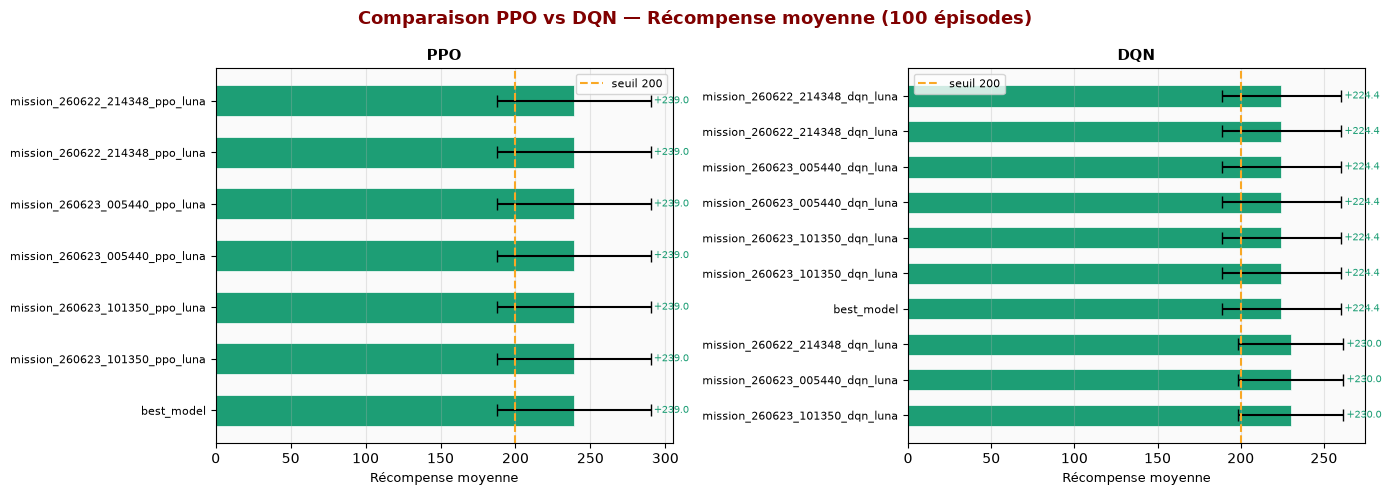

  Figure sauvegardée.....: comparaison_260623_183644_bar_ppo_vs_dqn.png


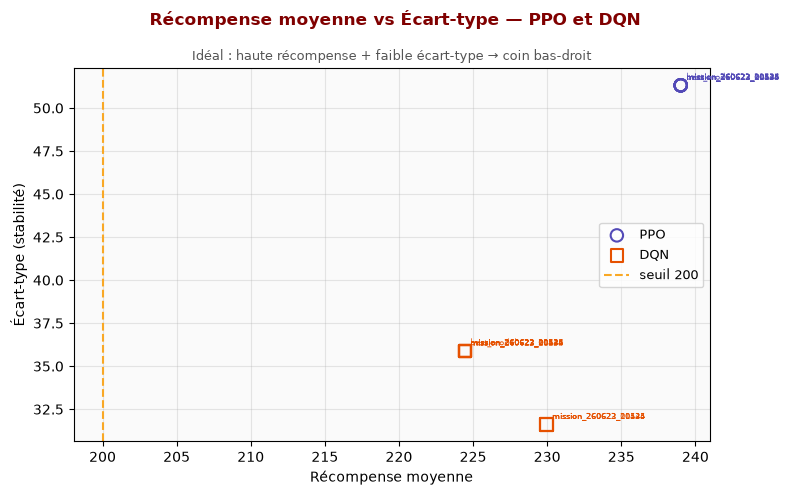

  Figure sauvegardée.....: comparaison_260623_183644_scatter_ppo_vs_dqn.png


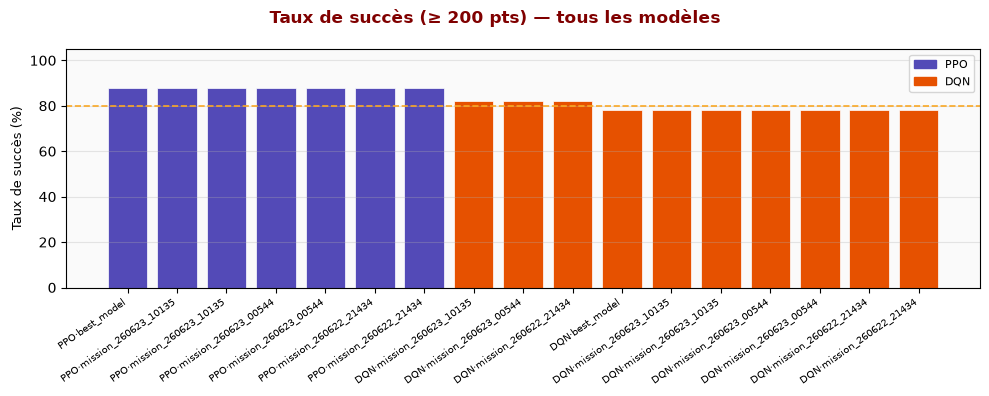

  Figure sauvegardée.....: comparaison_260623_183644_succes_ppo_vs_dqn.png


In [5]:
# ============================================================
# CELLULE — Graphiques comparatifs PPO vs DQN
# ============================================================

# — Bibliothèques visualisation
import json
import numpy             as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib             import Path

# ----------------------------------------------------------
# Chargement des résultats (depuis JSON ou depuis mémoire)
# ----------------------------------------------------------
# Option A — depuis mémoire (si cellule précédente exécutée)
data_ppo = resultats_comparatifs["PPO"]
data_dqn = resultats_comparatifs["DQN"]

# Option B — depuis fichier JSON (si kernel redémarré)
# chemin_json = MODELS / "comparaison_XXXXXX_ppo_vs_dqn.json"
# with open(chemin_json) as f:
#     rc = json.load(f)
# data_ppo = rc["PPO"]
# data_dqn = rc["DQN"]

# ----------------------------------------------------------
# Préparation des données pour les graphiques
# ----------------------------------------------------------
def _preparer(data, algo):
    """
    Extrait labels courts, means, stds et couleur par validité.
    """
    labels  = []
    means   = []
    stds    = []
    couleurs= []
    for nom, res in sorted(
        data.items(),
        key     = lambda x: x[1]["mean_reward"],
        reverse = True
    ):
        # Label court — 30 caractères max
        label = Path(nom).stem[:30]
        labels.append(label)
        means.append(res["mean_reward"])
        stds.append(res["std_reward"])
        couleurs.append(
            "#1D9E75" if res["valide"] else "#E24B4A"
        )
    return labels, means, stds, couleurs

labels_ppo, means_ppo, stds_ppo, cols_ppo = _preparer(data_ppo, "PPO")
labels_dqn, means_dqn, stds_dqn, cols_dqn = _preparer(data_dqn, "DQN")

# ----------------------------------------------------------
# Figure 1 — Récompense moyenne par modèle (PPO | DQN)
# ----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Comparaison PPO vs DQN — Récompense moyenne (100 épisodes)",
    fontsize=13, fontweight="bold", color="#800000"
)

for ax, labels, means, stds, cols, titre in [
    (axes[0], labels_ppo, means_ppo, stds_ppo, cols_ppo, "PPO"),
    (axes[1], labels_dqn, means_dqn, stds_dqn, cols_dqn, "DQN"),
]:
    y_pos = range(len(labels))
    ax.barh(
        y_pos, means,
        xerr       = stds,
        color      = cols,
        edgecolor  = "white",
        linewidth  = 0.5,
        capsize    = 4,
        height     = 0.6,
    )
    ax.axvline(200, color="#F9A825", linewidth=1.5,
               linestyle="--", label="seuil 200")
    ax.axvline(0,   color="#888",    linewidth=0.5,
               linestyle=":")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel("Récompense moyenne", fontsize=9)
    ax.set_title(titre, fontsize=11, fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(True, axis="x", alpha=0.3)
    ax.set_facecolor("#FAFAFA")

    # Valeurs sur les barres
    for i, (m, s) in enumerate(zip(means, stds)):
        ax.text(
            m + s + 2, i,
            f"{m:+.1f}",
            va="center", fontsize=7,
            color="#1D9E75" if m >= 200 else "#E24B4A"
        )

plt.tight_layout()
fig_path = MODELS / f"comparaison_{ts}_bar_ppo_vs_dqn.png"
plt.savefig(str(fig_path), dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print(f"  Figure sauvegardée.....: {fig_path.name}")

# ----------------------------------------------------------
# Figure 2 — Scatter mean vs std (stabilité)
# ----------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(8, 5))
fig2.suptitle(
    "Récompense moyenne vs Écart-type — PPO et DQN",
    fontsize=12, fontweight="bold", color="#800000"
)

# PPO
ax2.scatter(
    means_ppo, stds_ppo,
    color="None", edgecolors="#534AB7",
    s=80, linewidths=1.5,
    label="PPO", zorder=3
)
for lbl, x, y in zip(labels_ppo, means_ppo, stds_ppo):
    ax2.annotate(
        lbl[:20], (x, y),
        fontsize=6, color="#534AB7",
        xytext=(4, 4), textcoords="offset points"
    )

# DQN
ax2.scatter(
    means_dqn, stds_dqn,
    color="None", edgecolors="#E65100",
    s=80, linewidths=1.5,
    marker="s",
    label="DQN", zorder=3
)
for lbl, x, y in zip(labels_dqn, means_dqn, stds_dqn):
    ax2.annotate(
        lbl[:20], (x, y),
        fontsize=6, color="#E65100",
        xytext=(4, 4), textcoords="offset points"
    )

ax2.axvline(200, color="#F9A825", linewidth=1.5,
            linestyle="--", label="seuil 200")
ax2.set_xlabel("Récompense moyenne", fontsize=10)
ax2.set_ylabel("Écart-type (stabilité)", fontsize=10)
ax2.set_title(
    "Idéal : haute récompense + faible écart-type → coin bas-droit",
    fontsize=9, color="#555"
)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_facecolor("#FAFAFA")

plt.tight_layout()
fig2_path = MODELS / f"comparaison_{ts}_scatter_ppo_vs_dqn.png"
plt.savefig(str(fig2_path), dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print(f"  Figure sauvegardée.....: {fig2_path.name}")

# ----------------------------------------------------------
# Figure 3 — Taux de succès comparé
# ----------------------------------------------------------
fig3, ax3 = plt.subplots(figsize=(10, 4))
fig3.suptitle(
    "Taux de succès (≥ 200 pts) — tous les modèles",
    fontsize=12, fontweight="bold", color="#800000"
)

all_labels = (
    [f"PPO·{Path(n).stem[:20]}" for n in
     sorted(data_ppo, key=lambda x: data_ppo[x]["mean_reward"],
            reverse=True)]
  + [f"DQN·{Path(n).stem[:20]}" for n in
     sorted(data_dqn, key=lambda x: data_dqn[x]["mean_reward"],
            reverse=True)]
)
all_taux = (
    [data_ppo[n]["taux_succes"] for n in
     sorted(data_ppo, key=lambda x: data_ppo[x]["mean_reward"],
            reverse=True)]
  + [data_dqn[n]["taux_succes"] for n in
     sorted(data_dqn, key=lambda x: data_dqn[x]["mean_reward"],
            reverse=True)]
)
all_cols = (
    ["#534AB7"] * len(data_ppo)
  + ["#E65100"] * len(data_dqn)
)

x_pos = range(len(all_labels))
ax3.bar(x_pos, all_taux, color=all_cols,
        edgecolor="white", linewidth=0.5)
ax3.axhline(80, color="#F9A825", linewidth=1.2,
            linestyle="--", label="objectif 80 %")
ax3.set_xticks(x_pos)
ax3.set_xticklabels(all_labels, rotation=35,
                    ha="right", fontsize=7)
ax3.set_ylabel("Taux de succès (%)", fontsize=9)
ax3.set_ylim(0, 105)
ax3.legend(fontsize=8)
ax3.grid(True, axis="y", alpha=0.3)
ax3.set_facecolor("#FAFAFA")

patch_ppo = mpatches.Patch(color="#534AB7", label="PPO")
patch_dqn = mpatches.Patch(color="#E65100", label="DQN")
ax3.legend(handles=[patch_ppo, patch_dqn], fontsize=8)

plt.tight_layout()
fig3_path = MODELS / f"comparaison_{ts}_succes_ppo_vs_dqn.png"
plt.savefig(str(fig3_path), dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print(f"  Figure sauvegardée.....: {fig3_path.name}")

## CELLULE — Stress Test du Meilleur Modèle Global (Vent Activé)

In [6]:
# ============================================================
# CELLULE — Stress Test du Meilleur Modèle Global (Vent Activé)
# ============================================================

print("=" * 70)
print("STRESS TEST — ÉVALUATION DE LA GÉNÉRALISATION (VENT ACTIVÉ)")
print("=" * 70)

# 1. Détermination du meilleur modèle absolu sur les tests précédents
best_ppo_score = max([res["mean_reward"] for res in resultats_ppo.values()]) if resultats_ppo else -float('inf')
best_dqn_score = max([res["mean_reward"] for res in resultats_dqn.values()]) if resultats_dqn else -float('inf')

if best_ppo_score >= best_dqn_score:
    meilleur_nom = max(resultats_ppo, key=lambda x: resultats_ppo[x]["mean_reward"])
    algo_cls = PPO
    algo_str = "PPO"
else:
    meilleur_nom = max(resultats_dqn, key=lambda x: resultats_dqn[x]["mean_reward"])
    algo_cls = DQN
    algo_str = "DQN"

chemin_meilleur = MODELS / Path(meilleur_nom)
print(f"\n🏆 Modèle sélectionné pour le Stress Test : {chemin_meilleur.name} ({algo_str})")
print(f"   Performance initiale (sans vent) : {max(best_ppo_score, best_dqn_score):+.2f}")

# 2. Chargement du modèle
model_stress = algo_cls.load(str(chemin_meilleur))

# 3. Création de l'environnement avec VENT et TURBULENCES activés
# On passe explicitement les arguments de configuration à Gymnasium via make_env
env_stress = Monitor(make_env(
    ENV_ID, 
    render_mode=None, 
    seed=SEED + 500,        # Utilisation de seeds de test décalées pour éviter le par cœur
    enable_wind=True,       # Activation du vent !
    wind_power=15.0,        # Force du vent soutenue (défaut: 15.0)
    turbulence_power=2.0    # Turbulence aléatoire (défaut: 2.0)
))

# 4. Boucle d'évaluation (100 épisodes)
n_episodes_stress = 100
rewards_stress = []
n_succes_stress = 0

with tqdm(
    range(n_episodes_stress),
    desc    = f"  [STRESS TEST - WIND] {chemin_meilleur.name[:35]}",
    unit    = "ep",
    colour  = "#D32F2F",    # Barre rouge pour symboliser le stress test
    leave   = True,
) as pbar:
    for ep in pbar:
        obs, _ = env_stress.reset(seed=SEED + 500 + ep)
        total_r = 0.0
        terminated = False
        truncated = False

        while not (terminated or truncated):
            action, _ = model_stress.predict(obs, deterministic=True)
            obs, r, terminated, truncated, _ = env_stress.step(action)
            total_r += r

        rewards_stress.append(total_r)
        if total_r >= 200:
            n_succes_stress += 1

        if (ep + 1) % 10 == 0:
            pbar.set_postfix({
                "moy_vent": f"{np.mean(rewards_stress):+.1f}",
                "succès": f"{n_succes_stress}/{ep+1}",
            })

env_stress.close()

# 5. Analyse finale de Robustesse
mean_r_stress = np.mean(rewards_stress)
std_r_stress = np.std(rewards_stress)
taux_stress = (n_succes_stress / n_episodes_stress) * 100
valide_stress = mean_r_stress >= 200

critere_stress = "✓ ROBUSTE (Généralisation validée)" if valide_stress else "✗ SURAPPRIS (Sensible au vent)"

print("\n" + "-" * 70)
print("  RÉSULTATS DU STRESS TEST (LUNAR LANDER AVEC VENT)")
print("-" * 70)
print(f"  Récompense moyenne (Stress)....: {mean_r_stress:+.2f} ± {std_r_stress:.2f}")
print(f"  Taux de succès sous tempête....: {taux_stress:.1f} % ({n_succes_stress} / 100)")
print(f"  Statut de Généralisation.......: {critere_stress}")
print("-" * 70)

# Comparaison directe de la perte de performance
score_initial = resultats_ppo[meilleur_nom]["mean_reward"] if algo_str == "PPO" else resultats_dqn[meilleur_nom]["mean_reward"]
degradation = score_initial - mean_r_stress
print(f"  Impact du vent sur l'agent.....: -{degradation:.2f} points de récompense.")

STRESS TEST — ÉVALUATION DE LA GÉNÉRALISATION (VENT ACTIVÉ)

🏆 Modèle sélectionné pour le Stress Test : best_model.zip (PPO)
   Performance initiale (sans vent) : +239.01


  [STRESS TEST - WIND] best_model.zip:   0%|          | 0/100 [00:00<?, ?ep/s]


----------------------------------------------------------------------
  RÉSULTATS DU STRESS TEST (LUNAR LANDER AVEC VENT)
----------------------------------------------------------------------
  Récompense moyenne (Stress)....: +68.58 ± 144.70
  Taux de succès sous tempête....: 35.0 % (35 / 100)
  Statut de Généralisation.......: ✗ SURAPPRIS (Sensible au vent)
----------------------------------------------------------------------
  Impact du vent sur l'agent.....: -170.43 points de récompense.


## CELLULE — Réentraînement Robuste (Domain Randomization)

In [7]:
# ============================================================
# CELLULE — Réentraînement Robuste (Domain Randomization)
# ============================================================
import json
from pathlib import Path
from stable_baselines3 import DQN
from stable_baselines3.common.monitor import Monitor
from env_utils import make_env

# 1. Rutas y carga de la configuración original del JSON
FICHERO_CONFIG = "mission_260623_101350_dqn_lunarlander_226.json"
chemin_json = MODELS / FICHERO_CONFIG

print("============================================================")
print(f"CHARGEMENT DES HYPERPARAMÈTRES DEPUIS : {FICHERO_CONFIG}")
print("============================================================")

with open(chemin_json, "r", encoding="utf-8") as f:
    config = json.load(f)

# Extraer hiperparámetros del diccionario
hparams = config["hyperparametres"]
total_timesteps = config["total_timesteps"]

print(f"  Algorithme..........: {config['algorithme']}")
print(f"  Total Timesteps.....: {total_timesteps}")
print(f"  Learning Rate.......: {hparams['learning_rate']}")
print(f"  Buffer Size.........: {hparams['buffer_size']}")
print(f"  Exploration Frac....: {hparams['exploration_frac']}\n")

# 2. Creación del entorno de entrenamiento CON VIENTO MODERADO
print("Instanciation de l'environnement d'entraînement avec vent...")
env_train_robust = Monitor(make_env(
    ENV_ID, 
    render_mode=None, 
    seed=SEED,
    enable_wind=True,        # ¡Activamos el viento para que aprenda a compensar!
    wind_power=10.0,         # Iniciamos en 10.0 (un poco más suave que el 15.0 de test)
    turbulence_power=1.5     # Turbulencia moderada para romper trayectorias rígidas
))

# 3. Inicialización del modelo DQN con los hiperparámetros exactos recuperados
model_robust = DQN(
    policy               = config["policy"],
    env                  = env_train_robust,
    learning_rate        = hparams["learning_rate"],
    buffer_size          = hparams["buffer_size"],
    batch_size           = hparams["batch_size"],
    gamma                = hparams["gamma"],
    target_update_interval = hparams["target_update_int"],
    exploration_fraction = hparams["exploration_frac"],
    exploration_final_eps = hparams["exploration_final"],
    seed                 = SEED,
    verbose              = 0  # Cambiar a 1 para ver el progreso por consola si deseas
)

# 4. Lanzamiento del reentrenamiento robusto
print("\n============================================================")
print("DÉMARRAGE DE L'ENTRAÎNEMENT ROBUSTE (500k timesteps)")
print("============================================================")

model_robust.learn(
    total_timesteps=total_timesteps,
    progress_bar      = True
    )

# 5. Salvaguarda del nuevo modelo robusto
nom_robust_zip = f"mission_{ts}_dqn_lunarlander_robust.zip"
chemin_robust_zip = MODELS / nom_robust_zip
model_robust.save(str(chemin_robust_zip))

env_train_robust.close()

print("\n============================================================")
print("ENTRAÎNEMENT ROBUSTE TERMINÉ ET SAUVEGARDÉ")
print("============================================================")
print(f"  Nouveau modèle robust...: {nom_robust_zip}")

Output()

CHARGEMENT DES HYPERPARAMÈTRES DEPUIS : mission_260623_101350_dqn_lunarlander_226.json
  Algorithme..........: DQN
  Total Timesteps.....: 500000
  Learning Rate.......: 0.001
  Buffer Size.........: 100000
  Exploration Frac....: 0.25

Instanciation de l'environnement d'entraînement avec vent...

DÉMARRAGE DE L'ENTRAÎNEMENT ROBUSTE (500k timesteps)



ENTRAÎNEMENT ROBUSTE TERMINÉ ET SAUVEGARDÉ
  Nouveau modèle robust...: mission_260623_183644_dqn_lunarlander_robust.zip


## CELLULE — Évaluation du Modèle Robuste sous Tempête (Vent)

In [8]:
# ============================================================
# CELLULE — Évaluation du Modèle Robuste sous Tempête (Vent)
# ============================================================
import numpy as np
from pathlib import Path
from stable_baselines3 import DQN
from stable_baselines3.common.monitor import Monitor
from tqdm.notebook import tqdm
from env_utils import make_env

print("=" * 70)
print("ÉVALUATION DU MODÈLE ROBUSTE — STRESS TEST AVEC VENT")
print("=" * 70)

# 1. Configuration du chemin du modèle fraîchement entraîné
NOM_ROBUST = "mission_260623_174837_dqn_lunarlander_robust.zip"  # Tu archivo generado
chemin_robust = MODELS / NOM_ROBUST

if not chemin_robust.exists():
    print(f"✗ Fichier introuvable : {chemin_robust}")
else:
    # 2. Chargement du modèle DQN Robuste
    model_robust = DQN.load(str(chemin_robust))
    print(f"✓ Modèle chargé avec succès : {NOM_ROBUST}")

    # 3. Création de l'environnement de STRESS TEST (Vent maximal à 15.0)
    # On utilise SEED + 999 pour garantir des trajectoires 100% inconnues
    env_test_robust = Monitor(make_env(
        ENV_ID, 
        render_mode=None, 
        seed=SEED + 999,
        enable_wind=True,       # Vent activé !
        wind_power=15.0,        # Force maximale de stress test
        turbulence_power=2.0    # Turbulence maximale
    ))

    # 4. Boucle d'évaluation sur 100 épisodes
    n_episodes = 100
    rewards_robust = []
    n_succes_robust = 0

    with tqdm(
        range(n_episodes),
        desc    = "  [EVAL ROBUST - WIND]",
        unit    = "ep",
        colour  = "#1D9E75",    # Barra verde de esperanza y robustez
        leave   = True,
    ) as pbar:
        for ep in pbar:
            obs, _ = env_test_robust.reset(seed=SEED + 999 + ep)
            total_r = 0.0
            terminated = False
            truncated = False

            while not (terminated or truncated):
                action, _ = model_robust.predict(obs, deterministic=True)
                obs, r, terminated, truncated, _ = env_test_robust.step(action)
                total_r += r

            rewards_robust.append(total_r)
            if total_r >= 200:
                n_succes_robust += 1

            if (ep + 1) % 10 == 0:
                pbar.set_postfix({
                    "moy_vent": f"{np.mean(rewards_robust):+.1f}",
                    "succès": f"{n_succes_robust}/{ep+1}",
                })

    env_test_robust.close()

    # 5. Métriques finales
    mean_r_rob = np.mean(rewards_robust)
    std_r_rob = np.std(rewards_robust)
    taux_rob = (n_succes_robust / n_episodes) * 100
    valide_rob = mean_r_rob >= 200

    status = "✓ GENERALISATION VALIDÉE" if valide_rob else "✗ APPRENTISSAGE INSUFFISANT"

    print("\n" + "-" * 70)
    print("  RÉSULTATS FINAUX — AGENT ROBUSTE")
    print("-" * 70)
    print(f"  Récompense moyenne sous vent...: {mean_r_rob:+.2f} ± {std_r_rob:.2f}")
    print(f"  Taux de succès sous tempête....: {taux_rob:.1f} % ({n_succes_robust} / 100)")
    print(f"  Critère de validation (≥ 200)..: {status}")
    print("-" * 70)
    
    # Datos listos para tu JSON o DataFrame comparativo
    resultats_final_robust = {
        "mean_reward": round(mean_r_rob, 2),
        "std_reward": round(std_r_rob, 2),
        "n_succes": n_succes_robust,
        "taux_succes": round(taux_rob, 1),
        "valide": valide_rob
    }

ÉVALUATION DU MODÈLE ROBUSTE — STRESS TEST AVEC VENT
✓ Modèle chargé avec succès : mission_260623_174837_dqn_lunarlander_robust.zip


  [EVAL ROBUST - WIND]:   0%|          | 0/100 [00:00<?, ?ep/s]


----------------------------------------------------------------------
  RÉSULTATS FINAUX — AGENT ROBUSTE
----------------------------------------------------------------------
  Récompense moyenne sous vent...: +30.13 ± 158.59
  Taux de succès sous tempête....: 18.0 % (18 / 100)
  Critère de validation (≥ 200)..: ✗ APPRENTISSAGE INSUFFISANT
----------------------------------------------------------------------


## CELLULE — La Vraie Solution : Réentraînement PPO Robuste

In [9]:
# ============================================================
# CELLULE — Réentraînement ET Évaluation PPO Robuste (Vent)
# ============================================================
import numpy as np
from pathlib import Path
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from tqdm.notebook import tqdm
from env_utils import make_env

print("============================================================")
print("1. INITIALISATION ET ENTRAÎNEMENT PPO ROBUSTE")
print("============================================================")

# — Création de l'environnement d'entraînement avec vent modéré
env_train_ppo_robust = Monitor(make_env(
    ENV_ID, 
    render_mode=None, 
    seed=SEED,
    enable_wind=True,       
    wind_power=12.0,         # Viento para forzar al Actor-Critic a compensar
    turbulence_power=1.5     
))

# — Initialisation du modèle PPO avec entropie augmentée
model_ppo_robust = PPO(
    "MlpPolicy",
    env=env_train_ppo_robust,
    learning_rate=3e-4,
    gamma=0.99,
    ent_coef=0.01,           # Pousse à l'exploration sous les rafales
    clip_range=0.2,
    seed=SEED,
    verbose=0
)

print("Démarrage de l'apprentissage (500k timesteps)...")
model_ppo_robust.learn(
    total_timesteps=500000,
    progress_bar=True        # Corregido: añadida coma faltante
)

# — Sauvegarde du modèle
nom_ppo_robust_zip = f"mission_{ts}_ppo_lunarlander_robust.zip"
model_ppo_robust.save(str(MODELS / nom_ppo_robust_zip))
env_train_ppo_robust.close()
print(f"✓ Nouveau modèle sauvegardé : {nom_ppo_robust_zip}")


print("\n============================================================")
print("2. ÉVALUATION IMMÉDIATE DU MODÈLE ROBUSTE (STRESS TEST VENT MAX)")
print("============================================================")

# — Création de l'environnement de STRESS TEST (Vent maximal à 15.0)
# On utilise SEED + 888 pour garantir des trajectoires 100% inédites
env_test_ppo_robust = Monitor(make_env(
    ENV_ID, 
    render_mode=None, 
    seed=SEED + 888,
    enable_wind=True,       # Vent activé !
    wind_power=15.0,        # Force maximale de stress test
    turbulence_power=2.0    # Turbulence maximale
))

n_episodes = 100
rewards_robust = []
n_succes_robust = 0

with tqdm(
    range(n_episodes),
    desc    = "  [EVAL PPO ROBUST - WIND]",
    unit    = "ep",
    colour  = "#2E7D32",    # Vert foncé pour le succès attendu
    leave   = True,
) as pbar:
    for ep in pbar:
        obs, _ = env_test_ppo_robust.reset(seed=SEED + 888 + ep)
        total_r = 0.0
        terminated = False
        truncated = False

        while not (terminated or truncated):
            action, _ = model_ppo_robust.predict(obs, deterministic=True)
            obs, r, terminated, truncated, _ = env_test_ppo_robust.step(action)
            total_r += r

        rewards_robust.append(total_r)
        if total_r >= 200:
            n_succes_robust += 1

        if (ep + 1) % 10 == 0:
            pbar.set_postfix({
                "moy_vent": f"{np.mean(rewards_robust):+.1f}",
                "succès": f"{n_succes_robust}/{ep+1}",
            })

env_test_ppo_robust.close()

# — Métriques et bilan de robustesse
mean_r_rob = np.mean(rewards_robust)
std_r_rob = np.std(rewards_robust)
taux_rob = (n_succes_robust / n_episodes) * 100
valide_rob = mean_r_rob >= 200

status = "✓ GÉNÉRALISATION VALIDÉE (Robuste)" if valide_rob else "✗ APPRENTISSAGE INSUFFISANT"

print("\n" + "-" * 70)
print("  RÉSULTATS FINAUX — PPO ROBUSTE")
print("-" * 70)
print(f"  Récompense moyenne sous vent...: {mean_r_rob:+.2f} ± {std_r_rob:.2f}")
print(f"  Taux de succès sous tempête....: {taux_rob:.1f} % ({n_succes_robust} / 100)")
print(f"  Statut de la politique.........: {status}")
print("-" * 70)

# Stockage des résultats pour ton tableau comparatif
resultats_final_robust = {
    "mean_reward": round(mean_r_rob, 2),
    "std_reward": round(std_r_rob, 2),
    "n_succes": n_succes_robust,
    "taux_succes": round(taux_rob, 1),
    "valide": valide_rob
}

Output()

1. INITIALISATION ET ENTRAÎNEMENT PPO ROBUSTE
Démarrage de l'apprentissage (500k timesteps)...


✓ Nouveau modèle sauvegardé : mission_260623_183644_ppo_lunarlander_robust.zip

2. ÉVALUATION IMMÉDIATE DU MODÈLE ROBUSTE (STRESS TEST VENT MAX)


  [EVAL PPO ROBUST - WIND]:   0%|          | 0/100 [00:00<?, ?ep/s]


----------------------------------------------------------------------
  RÉSULTATS FINAUX — PPO ROBUSTE
----------------------------------------------------------------------
  Récompense moyenne sous vent...: +129.74 ± 132.25
  Taux de succès sous tempête....: 53.0 % (53 / 100)
  Statut de la politique.........: ✗ APPRENTISSAGE INSUFFISANT
----------------------------------------------------------------------
